In [73]:
# get 10 samples of the germans/arabic world and compare the pairwise edge-list-using the WJAC. Guve the result as a mean[SD]

In [74]:
import pandas as pd
import sys

sys.path.append("../networks")
sys.path.append("../")

import polars as pl
from functions.feat_network import get_edge_node_table
path = 'europe_before_1700'
path = 'non_europe_before_1700'


data = pd.read_csv(f"../networks/data/{path}.csv",index_col=[0])
data = data[data['region_name']=='Arabic world']
data

,wikidata_id,individual_name,region_code,region_name,birthyear,meta_occupation,meta_region
2197,Q1237726,Dominicus Gundissalinus,re_arabic_world,Arabic world,1115.0,linguist | philosopher,non_europe
2198,Q7413013,Samuel ibn Seneh Zarza,re_arabic_world,Arabic world,1360.0,philosopher,non_europe
2199,Q87474494,Mustafa ibn Fathallah al-Hamawi,re_arabic_world,Arabic world,1634.0,historian,non_europe
2201,Q4664590,Abd al-Rahman al-Tamanarti,re_arabic_world,Arabic world,1585.0,historian,non_europe
2207,Q67657447,Hamzah ibn ʻAbd Allah Nashiri,re_arabic_world,Arabic world,1430.0,botanist | historian,non_europe
...,...,...,...,...,...,...,...
2912,Q57252424,Ahmad ibn Khalil al-Khoei,re_arabic_world,Arabic world,1187.0,theologian,non_europe
2913,Q11362,Avempace,re_arabic_world,Arabic world,1080.0,botanist | astronomer | philosopher | mathemat...,non_europe
2914,Q1243803,George Elmacin,re_arabic_world,Arabic world,1223.0,historian,non_europe
2915,Q18397639,Mūsá ibn ʻUqbah,re_arabic_world,Arabic world,674.0,historian,non_europe


In [75]:
import numpy as np
import polars as pl
import pandas as pd

# Create 5 non-overlapping samples
samples_dict = {}
edges_dict = {}

# Get all unique wikidata_ids
all_ids = data['wikidata_id'].unique()

# Shuffle the IDs randomly
np.random.seed(42)  # For reproducibility
np.random.shuffle(all_ids)

# Split the IDs into 5 equal groups
id_splits = np.array_split(all_ids, 4)

# Create 5 samples with non-overlapping individuals
for i in range(1, 5):
    sample_key = f'sample_{i}'
    
    # Get the IDs for this sample
    sample_ids = id_splits[i-1]
    
    # Filter the dataset to only include these IDs
    sample = data[data['wikidata_id'].isin(sample_ids)]
    
    # Store the sample
    samples_dict[sample_key] = sample
    
    print(f"Sample {i} contains {len(sample)} rows with {len(sample_ids)} unique individuals")


# Process each sample to extract edges
for key, df in samples_dict.items():
    # Process occupation field - split by " | " and explode
    df["meta_occupation"] = df["meta_occupation"].apply(lambda x: x.split(" | "))
    df = df.explode("meta_occupation")
    
    # Keep only wikidata_id and meta_occupation columns
    df = df[["wikidata_id", "meta_occupation"]]
    
    # Remove duplicates and reset index
    df = df.drop_duplicates()
    df = df.reset_index(drop=True)
    
    # Rename columns to source and target
    df.columns = ["source", "target"]
    
    # Add weight column
    df["weight"] = 1

    # Convert to polars dataframe
    df = pl.from_pandas(df)
    
    # Get edge and node tables
    df_edge, df_nodes = get_edge_node_table(df)

    # Filter edges based on rank_count
    df_edge_filter = df_edge[
        df_edge["rank_count"] <= 3
    ]

    # Store filtered edges in the edges dictionary with the same key
    edges_dict[key] = df_edge_filter

Sample 1 contains 144 rows with 144 unique individuals
Sample 2 contains 144 rows with 144 unique individuals
Sample 3 contains 144 rows with 144 unique individuals
Sample 4 contains 143 rows with 143 unique individuals


### Compare the networks pairwise

In [76]:
import numpy as np

def prepare_edge_list(edge1, edge2):

    matrix1 = edge1.pivot(index ='source', columns='target', values='weight')
    matrix1 = matrix1.fillna(0)

    # Add the row[i]/col[i] when there is not information
    all_occupations = list(matrix1.index)

    # Add missing occupations
    for occupation in all_occupations:
        if occupation not in matrix1.columns:
            matrix1[occupation] = 0.0  # Add new column with zeros

    # Resetting the diagonal values to 0 for existing occupations (if necessary)
    for occupation in matrix1.columns:
        matrix1.at[occupation, occupation] = 0.0

    matrix2 = edge2.pivot(index ='source', columns='target', values='weight')
    matrix2 = matrix2.fillna(0)

        # Add the row[i]/col[i] when there is not information
    all_occupations = list(matrix2.index)

    # Add missing occupations
    for occupation in all_occupations:
        if occupation not in matrix2.columns:
            matrix2[occupation] = 0.0  # Add new column with zeros

    # Resetting the diagonal values to 0 for existing occupations (if necessary)
    for occupation in matrix2.columns:
        matrix2.at[occupation, occupation] = 0.0

    labels1 = list(matrix1.index)
    labels2 = list(matrix2.index)
    common_labels = set(labels1).intersection(set(labels2))

    matrix1 = matrix1[common_labels]
    matrix1 = matrix1.reset_index()
    matrix1 = matrix1[matrix1['source'].isin(common_labels)]
    matrix1 = matrix1.set_index('source')

    matrix2 = matrix2[common_labels]
    matrix2 = matrix2.reset_index()
    matrix2 = matrix2[matrix2['source'].isin(common_labels)]
    matrix2 = matrix2.set_index('source')

    matrix1 = matrix1.loc[common_labels, common_labels]
    matrix2 = matrix2.loc[common_labels, common_labels]

    return matrix1, matrix2


def weighted_jaccard_similarity(matrix1, matrix2):
    """
    Compute the Weighted Jaccard Similarity between two adjacency matrices.
    """
    # Ensure matrices are numpy arrays for element-wise operations
    matrix1 = np.array(matrix1)
    matrix2 = np.array(matrix2)

    # Calculate the minimum (intersection) and maximum (union) for each element
    min_matrix = np.minimum(matrix1, matrix2)
    max_matrix = np.maximum(matrix1, matrix2)

    # Sum the weights for intersection and union
    intersection_weight_sum = np.sum(min_matrix)
    union_weight_sum = np.sum(max_matrix)

    # Compute the similarity
    similarity = intersection_weight_sum / union_weight_sum if union_weight_sum != 0 else 0
    return similarity

  0%|          | 0/4 [00:00<?, ?it/s]/var/folders/lx/9b13r6ln63jb54_3xlf9b_380000gn/T/ipykernel_4243/3751044573.py:39: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  matrix1 = matrix1[common_labels]
/var/folders/lx/9b13r6ln63jb54_3xlf9b_380000gn/T/ipykernel_4243/3751044573.py:44: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  matrix2 = matrix2[common_labels]
/var/folders/lx/9b13r6ln63jb54_3xlf9b_380000gn/T/ipykernel_4243/3751044573.py:49: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  matrix1 = matrix1.loc[common_labels, common_labels]
/var/folders/lx/9b13r6ln63jb54_3xlf9b_380000gn/T/ipykernel_4243/3751044573.py:50: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  matrix2 = matrix2.loc[common_labels, common_labels]
/var/

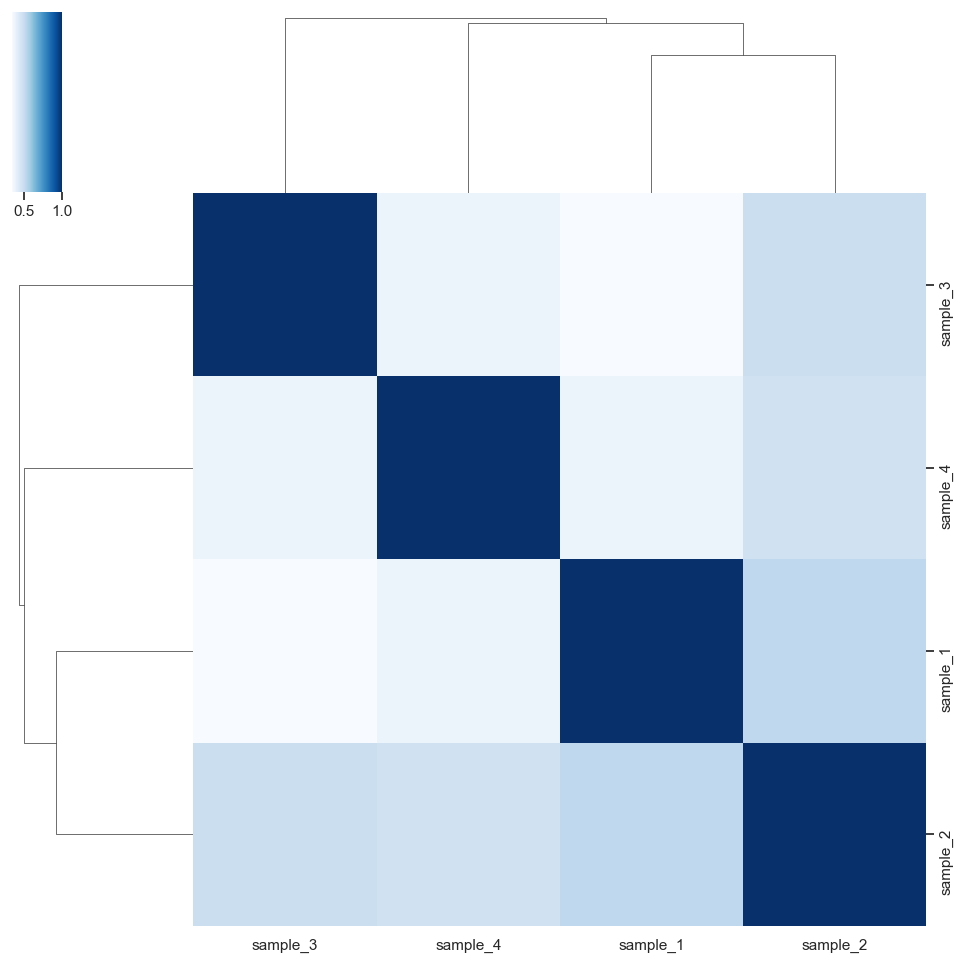

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
pd.options.mode.chained_assignment = None


# Create an empty DataFrame to store the ARI values
ari_df = pd.DataFrame(columns=['Dataset 1', 'Dataset 2', 'metric'])

# Iterate over pairs of datasets and compute the ARI
for dataset1_name, dataset1 in tqdm(edges_dict.items()):
    for dataset2_name, dataset2 in edges_dict.items():
        # Get the common elements based on the 'node' column

        dataset1 = dataset1[['source', 'target', 'weight']]
        dataset1['weight'] = (dataset1['weight'] - dataset1['weight'].min()) / (dataset1['weight'].max() - dataset1['weight'].min())
        dataset2 = dataset2[['source', 'target', 'weight']]
        dataset2['weight'] = (dataset2['weight'] - dataset2['weight'].min()) / (dataset2['weight'].max() - dataset2['weight'].min())

        matrix1, matrix2 = prepare_edge_list(dataset1, dataset2)
        matrix1, matrix2 = matrix1.to_numpy(), matrix2.to_numpy()

        score = weighted_jaccard_similarity(matrix1.flatten(), matrix2.flatten())
        try:
            score = round(score, 2)
        except:
            score = score
        ari_df = ari_df.append({'Dataset 1': dataset1_name, 'Dataset 2': dataset2_name, 'metric': score}, ignore_index=True)

# Print or analyze the ARI values as needed
matrix_df = ari_df.pivot(index='Dataset 1', columns='Dataset 2', values='metric')
matrix_df = matrix_df.astype(float)

# Create a hierarchical clustered heatmap using seaborn.clustermap
sns.set(font_scale=1.0)
clustered_heatmap = sns.clustermap(
    matrix_df,
    cmap='Blues',
    annot=False,
    fmt=".2f",
    cbar_kws={"orientation": "horizontal", "label": None},  # Hide the color bar (legend)
    method='ward'
)
clustered_heatmap.ax_heatmap.set_ylabel('')  # Set y-label to an empty string
clustered_heatmap.ax_heatmap.set_xlabel('')  # Set y-label to an empty string
clustered_heatmap.cax.set_visible(True)

# Customize the appearance of the clustermap
plt.title('')

# Show the plot
plt.show()

### Get the Mean and SD

In [78]:
import numpy as np

# Convert the dataframe to a numpy array for easier manipulation
matrix_array = matrix_df.to_numpy()

# Create a mask to exclude the diagonal (self-comparisons which are always 1.0)
mask = ~np.eye(matrix_array.shape[0], dtype=bool)

# Get all pairwise similarities (excluding self-comparisons)
pairwise_similarities = matrix_array[mask]

# Calculate mean and standard deviation
mean_similarity = np.mean(pairwise_similarities)
std_similarity = np.std(pairwise_similarities)

print(mean_similarity)
print(std_similarity)

0.43
0.06633249580710798
